# Glass Type Identification

## **problem definition**

I'm predicting the type of glass. This is a classification problem where the target variable is the type of glass. Success is defined by achieving a high f1 score, which balances both precision and recall. The features available for prediction include the physical property of the glass (Refractive index) and its chemical composition (Sodium, Magnesium, Aluminum, Silicon, Potassium, Calcium, Barium, Iron).

## **Data Understanding**

In [48]:
# Used Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.visualization import plot_feature_distribution

In [49]:
# loading the data
df = pd.read_csv("../data/glass.csv")

# removing exact duplicates
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [50]:
df.shape

(214, 10)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [52]:
# fixing data types
df['Type'] = df['Type'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   RI      214 non-null    float64 
 1   Na      214 non-null    float64 
 2   Mg      214 non-null    float64 
 3   Al      214 non-null    float64 
 4   Si      214 non-null    float64 
 5   K       214 non-null    float64 
 6   Ca      214 non-null    float64 
 7   Ba      214 non-null    float64 
 8   Fe      214 non-null    float64 
 9   Type    214 non-null    category
dtypes: category(1), float64(9)
memory usage: 15.4 KB


In [53]:
df.isnull().sum().sum() # total number of null values

np.int64(0)

In [54]:
df[df.duplicated(keep=False)]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [55]:
# removing exact duplicates
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
208,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
209,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
210,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
211,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


**Feature Meanings:**

1. **RI:** Refractive index of the glass.
2. **Na:** Sodium concentration in the glass.
3. **Mg:** Magnesium concentration in the glass.
4. **Al:** Aluminum concentration in the glass.
5. **Si:** Silicon concentration in the glass.
6. **K:** Potassium concentration in the glass.
7. **Ca:** Calcium concentration in the glass.
8. **Ba:** Barium concentration in the glass.
9. **Fe:** Iron concentration in the glass.
10. **Type:** Glass type.

**Unit Measurements:**

Weight percent in corresponding oxide, except for the Refractive Index.

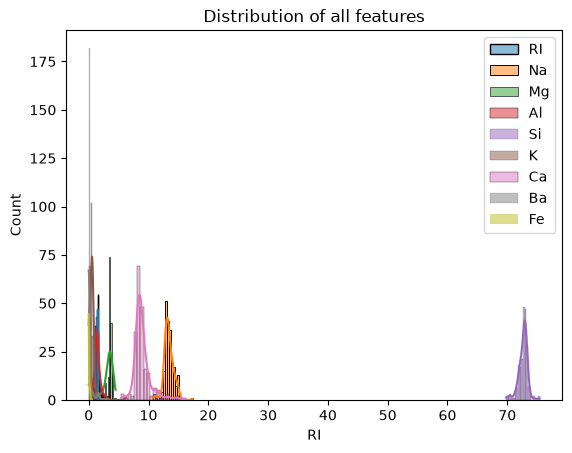

In [56]:
for feature in df.columns[:-1]:
    sns.histplot(
		data=df,
		x=feature,
        label=f"{feature}",
		bins=20,
		kde=True,
	)
plt.title("Distribution of all features")
plt.legend(loc="upper right")
plt.show()

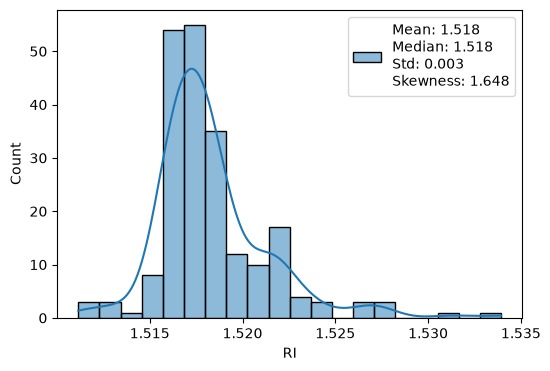

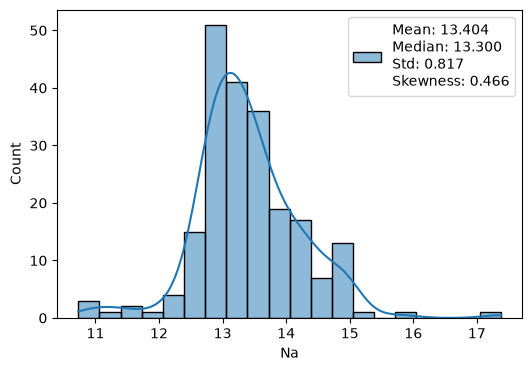

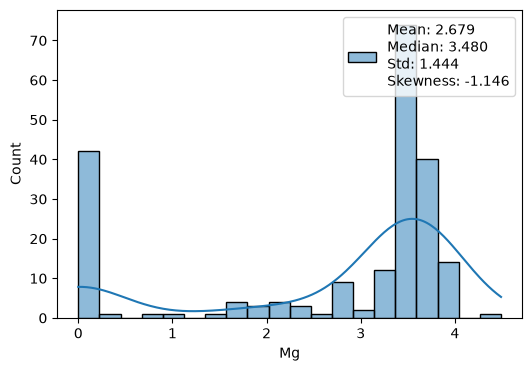

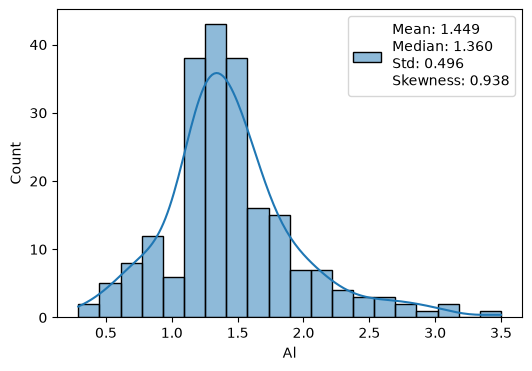

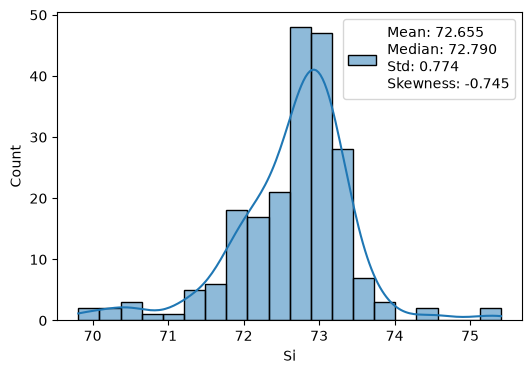

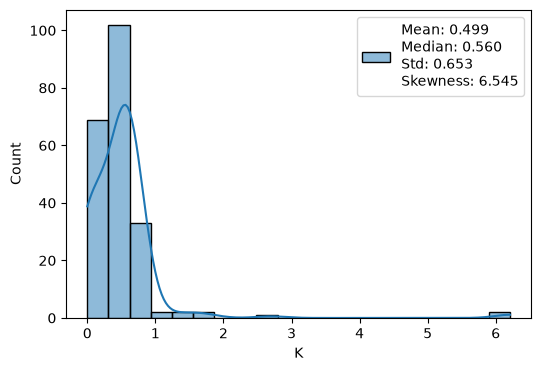

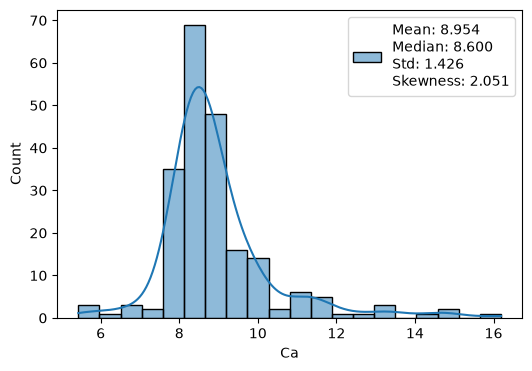

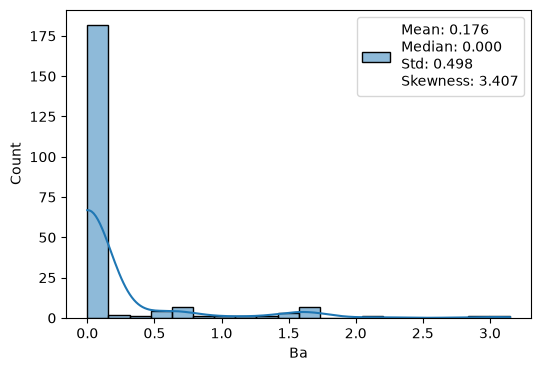

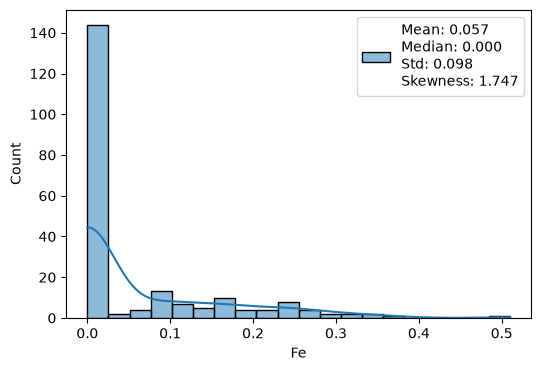

In [57]:
plot_feature_distribution(df)

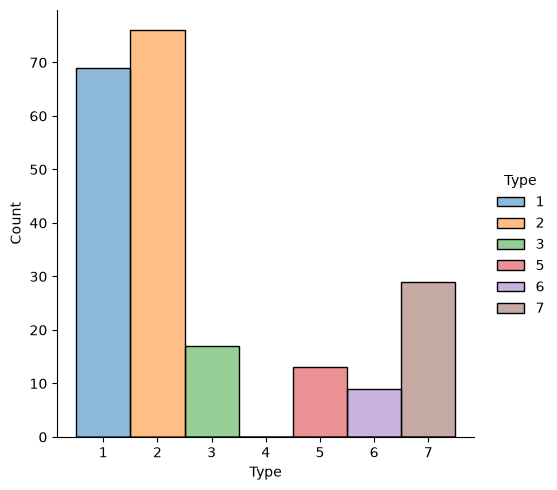

In [58]:
sns.displot(
	data=df,
    x="Type",
    hue="Type",
)